# Examples for Using **SproutCEX**
## An Appendix to *Learning Deterministic $\omega$-Automata from Smallest Counterexamples* by Jan Lohse

In this notebook we will both give an introduction on how to use the `sproutcex`
package, as well as present the examples given in the thesis in a more detailed and
interactive fashion.

If you are interested in a statistical analysis of the performance and the parameters
of **SproutCEX** you can look at the notebook `random_test_runner.ipynb`.
More details on the package can be found in the *documentation* or directly in the
source code hosted on *GitHub*.

In [1]:

from sproutcex import sproutcex
from sproutcex.graph_functions import Automaton, draw_automaton, generate_wdba
from sproutcex.sprout_dba import extend_state


## Introductory Examples

We start with some weak deterministic Büchi automata (wDBA) used as examples in related
papers.

We start by using the example from *On the Learnability of Infinitary Regular Sets* by
Maler and Pnueli. First we show how to define such an automaton and then on how we can
call **SproutCEX** to learn it with default parameters.

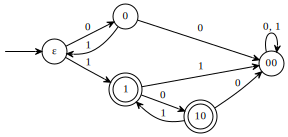

In [2]:
maler_pnueli = Automaton({
    "": (False, {"0": "0", "1": "1"}),
    "0": (False, {"0": "00", "1": ""}),
    "1": (True, {"0": "10", "1": "00"}),
    "00": (False, {"0": "00", "1": "00"}),
    "10": (True, {"0": "00", "1": "1"})
})

display(maler_pnueli)

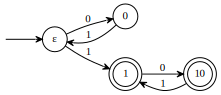

Found after 10 queries! The proportional reference is 32 queries. sprout_time=0.01s cex_search_time=0.01s


In [3]:
sproutcex(maler_pnueli);

You can see that it displays the number of equivalence queries (EQs) that was needed to
lean the automaton and a *proportional reference* for the number of queries.
This is computed as $|\Sigma| * |Q|^2$ and gives the maximum number of sample words
needed to identify the transition structure $\mathcal{T}$ of an automaton.

Furthermore, the cumulated computation time used both for building all query automata
with *Sprout* and the cumulated computation time used to simulate EQs is given.

Next let's look at an automaton used by Alluwaym et al. in *Efficient Learning of Weak
Deterministic Büchi Automata*.
This time we will set `verbose=True` to see all individual automata used to query the
EQ oracle.

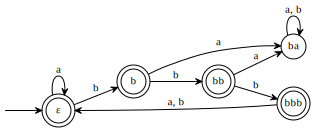

In [4]:
alluwaym_etal = Automaton({
    "": (True, {"a": "", "b": "b"}),
    "b": (True, {"a": "ba", "b": "bb"}),
    "bb": (True, {"a": "ba", "b": "bbb"}),
    "bbb": (True, {"a": "", "b": ""}),
    "ba": (False, {"a": "ba", "b": "ba"}),
})

alluwaym_etal

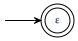

Received the positive counterexample ω(ε, a).


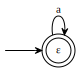

Received the positive counterexample ω(ε, b).


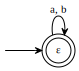

Received the negative counterexample ω(b, a).


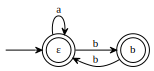

Received the negative counterexample ω(bb, a).


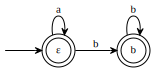

Received the positive counterexample ω(bbb, a).


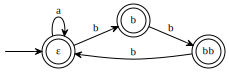

Received the positive counterexample ω(bbbb, a).


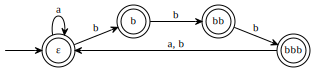

Found after 7 queries! The proportional reference is 32 queries. sprout_time=0.00s cex_search_time=0.01s


In [5]:
sproutcex(alluwaym_etal, verbose=True);

## Why no loop-first ordering

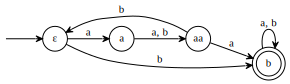

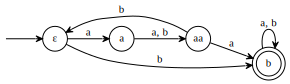

Found after 22 queries! The proportional reference is 32 queries. sprout_time=0.09s cex_search_time=0.03s


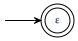

Received the positive counterexample ωˡ(ε, a).


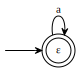

Received the positive counterexample ωˡ(b, a).


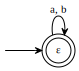

Received the negative counterexample ωˡ(ε, aab).


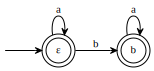

Received the positive counterexample ωˡ(bb, a).


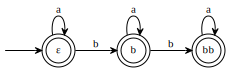

Received the positive counterexample ωˡ(bbb, a).


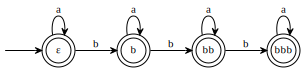

Received the positive counterexample ωˡ(bbbb, a).


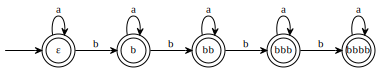

Received the positive counterexample ωˡ(bbbbb, a).


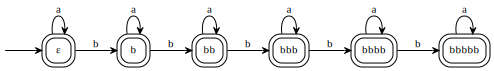

Received the positive counterexample ωˡ(bbbbbb, a).


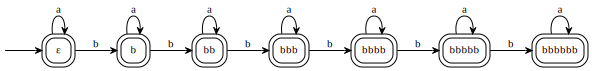

Received the positive counterexample ωˡ(bbbbbbb, a).


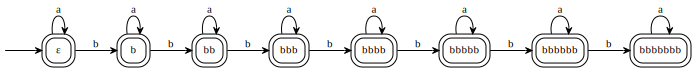

Received the positive counterexample ωˡ(bbbbbbbb, a).
Aborted after 10 queries. sprout_time=0.02s cex_search_time=0.01s


In [6]:
loop_order_cex = Automaton({
    '': (False, {'a': 'a', 'b': 'b'}),
    'a': (False, {'a': 'aa', 'b': 'aa'}),
    'b': (True, {'a': 'b', 'b': 'b'}),
    'aa': (False, {'a': 'b', 'b': ''})
})

display(loop_order_cex)
sproutcex(loop_order_cex)
sproutcex(loop_order_cex, ordering="loop", verbose=True, max_steps=10,
          typst_output=False);

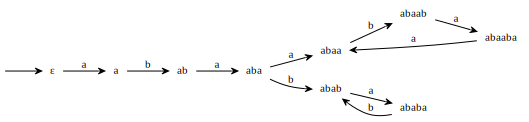

In [7]:
extend_state({"ab", "aba"})

## TODO
   - show $\Omega$-consistency methods
   - show orderings
   - thesis examples

In [8]:
import ipywidgets as widgets
from IPython.display import SVG, display

seeds = list(range(10))
automata = [generate_wdba(10, seed=seed) for seed in seeds]
frames = [SVG(draw_automaton(automaton).pipe(format="svg")) for automaton in automata]

def render(i):
    display(frames[i])

slider = widgets.IntSlider(min=0, max=len(frames)-1, step=1)
play = widgets.Play(interval=500, value=0, min=0, max=len(frames)-1)

widgets.jslink((play, "value"), (slider, "value"))

output = widgets.interactive_output(render, {"i": slider})

display(widgets.VBox([play, slider, output]))